In [1]:
import geopandas as gpd
import rasterio as rio
from rasterio.plot import show
from shapely.geometry import LineString

In [2]:
rio.open("../input/Bathymetry250m/nzbathy_2016.tif").crs

CRS.from_wkt('PROJCS["WGS 84 / Mercator 41",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_2SP"],PARAMETER["standard_parallel_1",-41],PARAMETER["central_meridian",100],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3994"]]')

In [3]:
dunepeak = gpd.read_file("../output/dunepeak/dunepeak_0.gpkg")
SLR_match = gpd.read_file("../input/SLR/SLR_match.gpkg")
SLR_match

DataSourceError: ../output/dunepeak/dunepeak_0.gpkg: No such file or directory

In [4]:
SLR_match.Unique_ID.duplicated().value_counts()

NameError: name 'SLR_match' is not defined

In [ ]:
SLR_geo = gpd.GeoSeries(
    gpd.points_from_xy(SLR_match.SLR_X, SLR_match.SLR_Y), crs=SLR_match.crs
)
SLR_geo

0      POINT (6313812.646 -3312583.194)
1      POINT (6313812.646 -3312583.194)
2      POINT (6313812.646 -3312583.194)
3      POINT (6313812.646 -3312583.194)
4      POINT (6313812.646 -3312583.194)
                     ...               
571    POINT (6316452.893 -3313327.514)
572    POINT (6316452.893 -3313327.514)
573    POINT (6316452.893 -3313327.514)
574    POINT (6316452.893 -3313327.514)
575    POINT (6316452.893 -3313327.514)
Length: 576, dtype: geometry

In [ ]:
lines = gpd.GeoSeries(
    SLR_match.apply(
        lambda row: gpd.GeoSeries(
            LineString([(row["point_X"], row["point_Y"]), (row["SLR_X"], row["SLR_Y"])])
        ),
        axis=1,
    )[0],
    crs=SLR_match.crs,
)
lines

0      LINESTRING (6314118.19 -3312299.733, 6313812.6...
1      LINESTRING (6314120.266 -3312308.926, 6313812....
2      LINESTRING (6314123.295 -3312317.905, 6313812....
3      LINESTRING (6314122.597 -3312327.722, 6313812....
4      LINESTRING (6314118.076 -3312348.69, 6313812.6...
                             ...                        
571    LINESTRING (6315779.442 -3313191.118, 6316452....
572    LINESTRING (6315759.334 -3313183.855, 6316452....
573    LINESTRING (6315750.07 -3313180.869, 6316452.8...
574    LINESTRING (6315741.431 -3313176.895, 6316452....
575    LINESTRING (6315735.065 -3313169.479, 6316452....
Name: 0, Length: 576, dtype: geometry

In [ ]:
m = SLR_match.explore()
SLR_geo.explore(m=m, color="red")
lines.explore(m=m, color="blue")

In [ ]:
transect_wp = gpd.read_file("../output/match/transect_wp_.gpkg")
transect_wp

,point_X,point_Y,transect_id,ux1,uy1,Unique_ID,index_right,wave_X,wave_Y,dist_m,n_intersections,mean_dist_to_coast,CD,geometry
0,5.613323e+06,-4.286012e+06,189112,-0.696213,0.717835,2.004094e+11,147,5.610765e+06,-4.277979e+06,8429.876554,1,5.182835,16.380001,POINT (5613322.787 -4286011.754)
1,5.613332e+06,-4.286006e+06,189111,-0.696214,0.717834,2.004094e+11,147,5.610765e+06,-4.277979e+06,8426.929661,1,3.592950,16.380001,POINT (5613331.919 -4286005.747)
2,5.613341e+06,-4.286000e+06,189110,-0.696215,0.717833,2.004094e+11,147,5.610765e+06,-4.277979e+06,8424.001698,1,1.997778,16.380001,POINT (5613341.056 -4285999.744)
3,5.613349e+06,-4.285993e+06,189109,-0.696216,0.717832,2.004094e+11,147,5.610765e+06,-4.277979e+06,8420.131886,1,1.560503,16.380001,POINT (5613349.452 -4285992.977)
4,5.613357e+06,-4.285986e+06,189108,-0.696217,0.717831,2.004095e+11,147,5.610765e+06,-4.277979e+06,8415.584237,1,1.957995,16.380001,POINT (5613357.313 -4285985.657)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213220,6.608651e+06,-3.407940e+06,26720,0.805890,0.592065,1.003877e+11,956,6.615129e+06,-3.408086e+06,6480.023407,1,12.340708,11.165211,POINT (6608650.565 -3407939.86)
213221,6.608662e+06,-3.407951e+06,26721,0.667978,0.744181,1.003877e+11,956,6.615129e+06,-3.408086e+06,6468.502138,1,12.170109,11.165211,POINT (6608661.851 -3407950.769)
213222,6.608669e+06,-3.407957e+06,26722,0.667977,0.744182,1.003877e+11,956,6.615129e+06,-3.408086e+06,6461.413955,1,14.176109,11.165211,POINT (6608668.807 -3407957.263)
213223,6.608677e+06,-3.407962e+06,26723,0.667976,0.744182,1.003877e+11,956,6.615129e+06,-3.408086e+06,6453.222702,1,14.480648,11.165211,POINT (6608676.898 -3407962.493)


In [ ]:
data = gpd.read_file("../output/brunnrule/brunnrule_buffer_10.gpkg")
data

,point_X,point_Y,transect_id,ux1,uy1,Unique_ID,index_right,wave_X,wave_Y,dist_m,n_intersections,mean_dist_to_coast,CD,choosefrom,B,S,L,R,tanbeta,beta_rad,beta_degree,x_new,y_new,geometry
0,5.613323e+06,-4.286012e+06,189112,-0.696213,0.717835,200409446488,147,5.610765e+06,-4.277979e+06,8429.876554,1,5.182835,16.380001,max,10.000,1.0,1634.662581,61.965979,0.016138,0.016136,0.924553,5.613366e+06,-4.286056e+06,POINT (5613322.787 -4286011.754)
1,5.613332e+06,-4.286006e+06,189111,-0.696214,0.717834,200409447515,147,5.610765e+06,-4.277979e+06,8426.929661,1,3.592950,16.380001,max,10.000,1.0,1634.662581,61.965979,0.016138,0.016136,0.924553,5.613375e+06,-4.286050e+06,POINT (5613331.919 -4286005.747)
2,5.613341e+06,-4.286000e+06,189110,-0.696215,0.717833,200409448528,147,5.610765e+06,-4.277979e+06,8424.001698,1,1.997778,16.380001,max,10.000,1.0,1634.662581,61.965979,0.016138,0.016136,0.924553,5.613384e+06,-4.286044e+06,POINT (5613341.056 -4285999.744)
3,5.613349e+06,-4.285993e+06,189109,-0.696216,0.717832,200409449534,147,5.610765e+06,-4.277979e+06,8420.131886,1,1.560503,16.380001,max,10.000,1.0,1634.662581,61.965979,0.016138,0.016136,0.924553,5.613393e+06,-4.286037e+06,POINT (5613349.452 -4285992.977)
4,5.613357e+06,-4.285986e+06,189108,-0.696217,0.717831,200409450537,147,5.610765e+06,-4.277979e+06,8415.584237,1,1.957995,16.380001,max,10.000,1.0,1634.662581,61.965979,0.016138,0.016136,0.924553,5.613400e+06,-4.286030e+06,POINT (5613357.313 -4285985.657)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213220,6.608651e+06,-3.407940e+06,26720,0.805890,0.592065,100387731531,956,6.615129e+06,-3.408086e+06,6480.023407,1,12.340708,11.165211,coast,5.428,1.0,2182.099643,131.505566,0.007604,0.007604,0.435683,6.608545e+06,-3.408018e+06,POINT (6608650.565 -3407939.86)
213221,6.608662e+06,-3.407951e+06,26721,0.667978,0.744181,100387732978,956,6.615129e+06,-3.408086e+06,6468.502138,1,12.170109,11.165211,coast,5.416,1.0,1932.099643,116.523429,0.008582,0.008582,0.491698,6.608584e+06,-3.408037e+06,POINT (6608661.851 -3407950.769)
213222,6.608669e+06,-3.407957e+06,26722,0.667977,0.744182,100387733979,956,6.615129e+06,-3.408086e+06,6461.413955,1,14.176109,11.165211,coast,5.429,1.0,1932.099643,116.432147,0.008589,0.008588,0.492084,6.608591e+06,-3.408044e+06,POINT (6608668.807 -3407957.263)
213223,6.608677e+06,-3.407962e+06,26723,0.667976,0.744182,100387734980,956,6.615129e+06,-3.408086e+06,6453.222702,1,14.480648,11.165211,coast,6.112,1.0,1932.099643,111.829369,0.008942,0.008942,0.512336,6.608602e+06,-3.408046e+06,POINT (6608676.898 -3407962.493)


In [ ]:
gpd.points_from_xy(data.x_new, data.y_new, crs=data.crs)

<GeometryArray>
[<POINT (5613365.928 -4286056.235)>, <POINT (5613375.061 -4286050.228)>,
 <POINT (5613384.198 -4286044.225)>, <POINT (5613392.594 -4286037.458)>,
 <POINT (5613400.454 -4286030.139)>,  <POINT (5613408.315 -4286022.82)>,
 <POINT (5613415.918 -4286015.236)>,  <POINT (5613425.931 -4286003.75)>,
   <POINT (5613432.9 -4285995.558)>, <POINT (5613439.869 -4285987.366)>,
 ...
 <POINT (6608518.707 -3407977.702)>, <POINT (6608523.343 -3407986.102)>,
 <POINT (6608530.256 -3407992.829)>,  <POINT (6608536.15 -3408000.305)>,
 <POINT (6608542.573 -3408007.392)>,  <POINT (6608544.586 -3408017.72)>,
 <POINT (6608584.016 -3408037.484)>, <POINT (6608591.033 -3408043.909)>,
 <POINT (6608602.198 -3408045.714)>, <POINT (6608610.334 -3408050.894)>]
Length: 213225, dtype: geometry

In [ ]:
gpd.points_from_xy(data.wave_X, data.wave_Y, crs=data.crs).to_crs(4326)

<GeometryArray>
[<POINT (166.688 -45.437)>, <POINT (166.688 -45.437)>,
 <POINT (166.688 -45.437)>, <POINT (166.688 -45.437)>,
 <POINT (166.688 -45.437)>, <POINT (166.688 -45.437)>,
 <POINT (166.688 -45.437)>, <POINT (166.688 -45.437)>,
 <POINT (166.688 -45.437)>, <POINT (166.688 -45.437)>,
 ...
 <POINT (178.625 -37.688)>, <POINT (178.625 -37.688)>,
 <POINT (178.625 -37.688)>, <POINT (178.625 -37.688)>,
 <POINT (178.625 -37.688)>, <POINT (178.625 -37.688)>,
 <POINT (178.625 -37.688)>, <POINT (178.625 -37.688)>,
 <POINT (178.625 -37.688)>, <POINT (178.625 -37.688)>]
Length: 213225, dtype: geometry

In [ ]:
data.crs

<Projected CRS: EPSG:3994>
Name: WGS 84 / Mercator 41
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Southwestern Pacific Ocean and Southern Ocean areas surrounding New Zealand.
- bounds: (155.0, -60.0, -169.99, -25.0)
Coordinate Operation:
- name: Mercator 41
- method: Mercator (variant B)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
data = pd.read_parquet("brunnrule_b_10_medium_confidence_y_2150_s_4.5_p_0.5.parquet")
pd.set_option("display.max_columns", None)
data

,Unique_ID,dist_m,mean_dist_to_coast,CD,B,L,R,tanbeta,S_SLR,R_SLR,ER_SLR,lat,lon,wave_lat,wave_lon
0,200409446488,8429.876554,5.182835,16.380001,10.000,1634.662581,61.965979,0.016138,0.97,60.107000,0.462362,-45.504673,166.717899,-45.4375,166.6875
1,200409447515,8426.929661,3.592950,16.380001,10.000,1634.662581,61.965979,0.016138,0.97,60.107000,0.462362,-45.504623,166.718008,-45.4375,166.6875
2,200409448528,8424.001698,1.997778,16.380001,10.000,1634.662581,61.965979,0.016138,0.97,60.107000,0.462362,-45.504573,166.718116,-45.4375,166.6875
3,200409449534,8420.131886,1.560503,16.380001,10.000,1634.662581,61.965979,0.016138,0.97,60.107000,0.462362,-45.504516,166.718216,-45.4375,166.6875
4,200409450537,8415.584237,1.957995,16.380001,10.000,1634.662581,61.965979,0.016138,0.97,60.107000,0.462362,-45.504455,166.718309,-45.4375,166.6875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213220,100387731531,6480.023407,12.340708,11.165211,5.428,2182.099643,131.505566,0.007604,0.99,130.190510,1.001465,-37.686115,178.548001,-37.6875,178.6250
213221,100387732978,6468.502138,12.170109,11.165211,5.416,1932.099643,116.523429,0.008582,0.99,115.358195,0.887371,-37.686218,178.548135,-37.6875,178.6250
213222,100387733979,6461.413955,14.176109,11.165211,5.429,1932.099643,116.432147,0.008589,0.99,115.267826,0.886676,-37.686280,178.548217,-37.6875,178.6250
213223,100387734980,6453.222702,14.480648,11.165211,6.112,1932.099643,111.829369,0.008942,0.99,110.711076,0.851624,-37.686329,178.548314,-37.6875,178.6250


In [ ]:
data.R.isna().value_counts()

R
False    190504
True      22721
Name: count, dtype: int64

In [ ]:
gpd.points_from_xy(data.point_X, data.point_Y, crs=2193).to_crs(4326)

<GeometryArray>
[<POINT (-54.135 -40.536)>, <POINT (-54.136 -40.536)>,
 <POINT (-54.136 -40.536)>, <POINT (-54.136 -40.536)>,
 <POINT (-54.136 -40.536)>, <POINT (-54.136 -40.536)>,
 <POINT (-54.136 -40.536)>, <POINT (-54.136 -40.536)>,
 <POINT (-54.136 -40.536)>, <POINT (-54.136 -40.536)>,
 ...
 <POINT (-66.574 -40.537)>, <POINT (-66.574 -40.537)>,
 <POINT (-66.574 -40.537)>, <POINT (-66.574 -40.537)>,
 <POINT (-66.574 -40.537)>, <POINT (-66.574 -40.536)>,
 <POINT (-66.574 -40.536)>, <POINT (-66.574 -40.536)>,
 <POINT (-66.574 -40.536)>, <POINT (-66.574 -40.536)>]
Length: 213225, dtype: geometry

In [ ]:
import os
import pandas as pd
import geopandas as gpd

# input loc
buffer_dist = 10
confidence_level = "medium_confidence"
year = 2150
percentile = "0.5"
scenario = 4.5

# Note the typo here, brunnrule instead of bruunrule
inputfilename = f"../output/brunnrule/brunnrule_buffer_{buffer_dist}.gpkg"
SLR_matchfile = f"../input/SLR/SLR_match.gpkg"
SLR_scenariofile = f"../input/SLR/{confidence_level}_y_{year}_s_{scenario}.gpkg"
currentyear = 2020  # The current year is used to calculate the erosion rate. Ideally, it should correspond to the mean date of the most recent shoreline points.

# SLR data
SLR_match = gpd.read_file(SLR_matchfile)
SLR_scenario = gpd.read_file(SLR_scenariofile)
print(SLR_matchfile, SLR_match.crs)
print(SLR_scenariofile, SLR_scenario.crs)
data = gpd.read_file(inputfilename)
print(inputfilename, data.crs)
SLR_scenario = SLR_scenario.to_crs(data.crs)
print(SLR_scenariofile, SLR_scenario.crs)
years_delta = year - currentyear

# Vectorized lookup to avoid per-row filtering
# Ensure indices are unique before mapping
site_lookup = SLR_match.drop_duplicates(subset="Unique_ID").set_index("Unique_ID")[
    "Site ID"
]
scenario_lookup = SLR_scenario.drop_duplicates(subset="Site ID").set_index("Site ID")[
    percentile
]

data["Site ID"] = data["Unique_ID"].map(site_lookup)
data["S_SLR"] = data["Site ID"].map(scenario_lookup)
data["R_SLR"] = data["S_SLR"] * data["R"]
data["ER_SLR"] = data["R_SLR"] / years_delta

data["lat"] = data.geometry.to_crs(4326).y
data["lon"] = data.geometry.to_crs(4326).x

wave_points = gpd.points_from_xy(data.wave_X, data.wave_Y, crs=data.crs).to_crs(4326)
data["wave_lat"] = wave_points.y
data["wave_lon"] = wave_points.x

cols_for_map = [
    "Unique_ID",
    "dist_m",
    "mean_dist_to_coast",
    "CD",
    "B",
    "L",
    "R",
    "tanbeta",
    "S_SLR",
    "R_SLR",
    "ER_SLR",
    "lat",
    "lon",
    "wave_lat",
    "wave_lon",
]
print(data[cols_for_map])

../input/SLR/SLR_match.gpkg EPSG:2193
../input/SLR/medium_confidence_y_2150_s_4.5.gpkg EPSG:4326
../output/brunnrule/brunnrule_buffer_10.gpkg EPSG:3994
../input/SLR/medium_confidence_y_2150_s_4.5.gpkg EPSG:3994
           Unique_ID       dist_m  mean_dist_to_coast         CD       B  \
0       200409446488  8429.876554            5.182835  16.380001  10.000   
1       200409447515  8426.929661            3.592950  16.380001  10.000   
2       200409448528  8424.001698            1.997778  16.380001  10.000   
3       200409449534  8420.131886            1.560503  16.380001  10.000   
4       200409450537  8415.584237            1.957995  16.380001  10.000   
...              ...          ...                 ...        ...     ...   
213220  100387731531  6480.023407           12.340708  11.165211   5.428   
213221  100387732978  6468.502138           12.170109  11.165211   5.416   
213222  100387733979  6461.413955           14.176109  11.165211   5.429   
213223  100387734980  6453.22

In [ ]:
SLR_scenario

,Site ID,Lon,Lat,Vertical Rate (mm/yr),Vertical Rate - BOP corrected (mm/yr),1-sigma uncertainty (mm/yr),Number of obs,Quality Factor,Average distance between coastal point and observations,Confidence,site,year,0.17,0.5,0.83,SSP,scenario,geometry
0,0,173.117510,-34.740926,-1.320000,-1.320000,15.485643,1,4.333333,39.246499,medium_confidence,0,2150,0.72,1.02,1.39,SSP2,4.5,POINT (6151755.239 -3102087.146)
1,1,173.127726,-34.756665,-1.320000,-1.320000,14.613627,1,4.333333,37.272582,medium_confidence,1,2150,0.72,1.02,1.39,SSP2,4.5,POINT (6152614.764 -3103691.469)
2,2,173.143557,-34.768840,-1.320000,-1.320000,14.319939,1,4.333333,35.498780,medium_confidence,2,2150,0.71,1.02,1.39,SSP2,4.5,POINT (6153946.708 -3104932.714)
3,3,173.154531,-34.767581,-1.320000,-1.320000,14.277605,1,4.333333,35.310875,medium_confidence,3,2150,0.71,1.02,1.39,SSP2,4.5,POINT (6154870.008 -3104804.35)
4,4,173.147358,-34.775750,-1.320000,-1.320000,14.047993,1,4.333333,34.656364,medium_confidence,4,2150,0.71,1.02,1.39,SSP2,4.5,POINT (6154266.506 -3105637.273)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8168,8174,174.217764,-35.210063,-0.446163,-0.446163,2.584324,31,4.000000,8.846345,medium_confidence,8174,2150,0.71,1.02,1.38,SSP2,4.5,POINT (6244325.313 -3150041.108)
8169,8175,174.229635,-35.204969,-0.268417,-0.268417,2.918795,16,4.000000,8.622976,medium_confidence,8175,2150,0.71,1.02,1.38,SSP2,4.5,POINT (6245324.082 -3149518.919)
8170,8176,173.974770,-40.775383,-2.861836,-2.861836,1.809444,288,2.333333,5.725164,medium_confidence,8176,2150,0.70,0.98,1.33,SSP2,4.5,POINT (6223880.968 -3742230.065)
8171,8177,173.963529,-40.780559,-2.870703,-2.870703,1.704356,374,2.000000,6.063013,medium_confidence,8177,2150,0.70,0.98,1.33,SSP2,4.5,POINT (6222935.204 -3742802.94)


In [2]:
import pandas as pd
import geopandas as gpd

df = pd.read_csv("bruunrule_JaMoNoRaSoWa_b_10.csv")
df

,Unique_ID,dist_m,mean_dist_to_coast,CD,B,L,R,tanbeta,Site ID,lat,lon,wave_lat,wave_lon
0,200409446488,8429.876554,5.182835,16.380001,10.000,1634.662581,61.965979,0.016138,5440,-45.504673,166.717899,-45.4375,166.6875
1,200409447515,8426.929661,3.592950,16.380001,10.000,1634.662581,61.965979,0.016138,5440,-45.504623,166.718008,-45.4375,166.6875
2,200409448528,8424.001698,1.997778,16.380001,10.000,1634.662581,61.965979,0.016138,5440,-45.504573,166.718116,-45.4375,166.6875
3,200409449534,8420.131886,1.560503,16.380001,10.000,1634.662581,61.965979,0.016138,5440,-45.504516,166.718216,-45.4375,166.6875
4,200409450537,8415.584237,1.957995,16.380001,10.000,1634.662581,61.965979,0.016138,5440,-45.504455,166.718309,-45.4375,166.6875
...,...,...,...,...,...,...,...,...,...,...,...,...,...
213220,100387731531,6480.023407,12.340708,11.165211,5.428,2182.099643,131.505566,0.007604,2039,-37.686115,178.548001,-37.6875,178.6250
213221,100387732978,6468.502138,12.170109,11.165211,5.416,1932.099643,116.523429,0.008582,2039,-37.686218,178.548135,-37.6875,178.6250
213222,100387733979,6461.413955,14.176109,11.165211,5.429,1932.099643,116.432147,0.008589,2039,-37.686280,178.548217,-37.6875,178.6250
213223,100387734980,6453.222702,14.480648,11.165211,6.112,1932.099643,111.829369,0.008942,2039,-37.686329,178.548314,-37.6875,178.6250


In [3]:
df.Unique_ID.dtype

dtype('int64')

In [4]:
ni = gpd.read_file("../input/Merged Intersects_UniqueID/NorthIsland_Intersects.shp")
ni

,ShorelineI,BaselineID,Distance,IntersectX,IntersectY,Uncertaint,Unique_ID,Date,geometry
0,01/03/2011,0.0,-37.16,1.730591e+06,5.908710e+06,8.59,1.006327e+11,2011-01-03,POINT Z (1730590.982 5908710.362 0)
1,08/19/1960,0.0,-51.70,1.730600e+06,5.908699e+06,3.76,1.006327e+11,1960-08-19,POINT Z (1730600.339 5908699.234 0)
2,01/04/2017,0.0,-32.09,1.730588e+06,5.908714e+06,2.94,1.006327e+11,2017-01-04,POINT Z (1730587.72 5908714.241 0)
3,01/02/2004,0.0,-48.27,1.730598e+06,5.908702e+06,10.05,1.006327e+11,2004-01-02,POINT Z (1730598.132 5908701.858 0)
4,01/04/2022,0.0,-23.18,1.730582e+06,5.908721e+06,2.07,1.006327e+11,2022-01-04,POINT Z (1730581.983 5908721.063 0)
...,...,...,...,...,...,...,...,...,...
914496,02/21/2021,0.0,-104.61,1.800540e+06,5.395670e+06,1.02,1.004660e+11,2021-02-21,POINT Z (1800539.73 5395670.271 0)
914497,09/24/1995,0.0,-69.89,1.800538e+06,5.395636e+06,5.64,1.004660e+11,1995-09-24,POINT Z (1800538.365 5395635.582 0)
914498,04/12/1973,0.0,-46.92,1.800527e+06,5.395613e+06,4.73,1.004661e+11,1973-04-12,POINT Z (1800527.469 5395613.018 0)
914499,02/21/2021,0.0,-104.80,1.800530e+06,5.395671e+06,1.02,1.004661e+11,2021-02-21,POINT Z (1800529.745 5395670.85 0)


In [5]:
rates = gpd.read_file("../input/nzccd-coastal-change-rates.shp.zip")
rates

,ShrCount,LRR,LR2,LCI,LSE,EPR,EPRunc,NSM,SCE,WLR,WR2,WCI,WSE,TCD,Region,UniqueID,Start_date,End_date,Duration,geometry
0,3.0,0.44,1.00,0.04,0.17,0.44,0.12,15.46,15.46,0.44,1.00,0.08,0.10,0.00,WestCoast,2.005236e+11,1988-02-18,2023-01-27,34,POINT (1453101.648 5304753.341)
1,3.0,0.53,1.00,0.09,0.37,0.52,0.12,18.29,18.29,0.53,1.00,0.17,0.22,10.00,WestCoast,2.005236e+11,1988-02-18,2023-01-27,34,POINT (1453099.538 5304743.566)
2,3.0,0.63,0.99,0.36,1.47,0.65,0.13,22.79,22.79,0.64,0.97,0.68,0.87,20.00,WestCoast,2.005236e+11,1988-02-18,2023-01-27,34,POINT (1453097.462 5304733.784)
3,4.0,0.24,0.51,0.47,9.57,0.25,0.06,18.66,25.29,0.27,0.58,0.48,2.90,30.00,WestCoast,2.005236e+11,1948-04-01,2023-01-27,74,POINT (1453095.386 5304724.001)
4,5.0,0.31,0.53,0.40,10.55,0.26,0.06,19.15,31.85,0.36,0.69,0.33,2.80,40.00,WestCoast,2.005236e+11,1948-04-01,2023-01-27,74,POINT (1453093.311 5304714.219)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225116,8.0,0.55,0.94,0.11,3.78,0.46,0.05,32.80,36.19,0.53,0.96,0.08,1.18,3314.75,Southland,2.003355e+11,1952-02-15,2023-04-09,71,POINT (1233351.728 4846552.755)
225117,8.0,0.53,0.92,0.12,4.26,0.44,0.05,31.16,34.49,0.52,0.96,0.08,1.18,3324.75,Southland,2.003355e+11,1952-02-15,2023-04-09,71,POINT (1233342.276 4846571.284)
225118,8.0,0.50,0.85,0.16,5.55,0.40,0.05,28.75,33.22,0.51,0.95,0.10,1.36,3334.75,Southland,2.003355e+11,1952-02-15,2023-04-09,71,POINT (1233337.68 4846580.293)
225119,8.0,0.48,0.79,0.20,6.73,0.39,0.05,27.94,35.58,0.51,0.93,0.11,1.58,3344.75,Southland,2.003355e+11,1952-02-15,2023-04-09,71,POINT (1233333.084 4846589.302)


In [6]:
rates.Region.value_counts()

Region
Northland      34134
Canterbury     21881
WestCoast      20990
Taranaki       17050
Waikato        16589
Otago          15425
BayOfPlenty    13902
HawkesBay      13494
Southland      12266
Auckland       11494
Wellington     11154
Manawatu       10443
Tasman         10102
Gisborne        8078
Marlborough     5083
Nelson          3036
Name: count, dtype: int64

In [7]:
rates.UniqueID = rates.UniqueID.astype(int)

In [8]:
df.Unique_ID.isin(rates.UniqueID).value_counts()

Unique_ID
True     209896
False      3329
Name: count, dtype: int64

In [9]:
pd.set_option("display.max_columns", None)

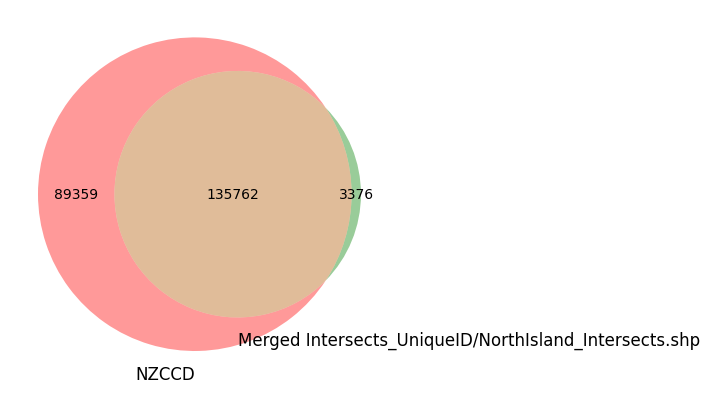

In [ ]:
from matplotlib_venn import venn2

venn2(
    [set(rates.UniqueID), set(ni.Unique_ID)],
    set_labels=["NZCCD", "Merged Intersects_UniqueID/NorthIsland_Intersects.shp"],
)

In [12]:
rates[rates.Region == "Auckland"]

,ShrCount,LRR,LR2,LCI,LSE,EPR,EPRunc,NSM,SCE,WLR,WR2,WCI,WSE,TCD,Region,UniqueID,Start_date,End_date,Duration,geometry
1657,9.0,-0.03,0.05,0.10,3.54,0.03,0.07,1.54,11.06,-0.04,0.10,0.08,0.92,4121.8500,Auckland,101000663495,1961-11-02,2023-05-16,61,POINT (1779314.724 5927940.661)
1658,9.0,0.00,0.00,0.11,3.78,0.11,0.07,6.47,11.79,0.00,0.00,0.10,1.15,4131.8500,Auckland,101000662495,1961-11-02,2023-05-16,61,POINT (1779319.773 5927949.294)
1659,8.0,-0.01,0.00,0.12,3.78,0.02,0.07,1.02,11.18,-0.01,0.02,0.09,0.95,4141.8500,Auckland,101000661493,1961-11-02,2022-12-27,61,POINT (1779325.358 5927957.607)
1660,8.0,0.01,0.01,0.12,3.50,0.04,0.07,2.27,10.32,0.00,0.00,0.08,0.86,4151.8500,Auckland,101000660488,1961-11-02,2022-12-27,61,POINT (1779331.375 5927965.664)
1661,8.0,0.01,0.01,0.11,3.25,0.04,0.07,2.52,9.37,-0.01,0.01,0.08,0.82,4161.8500,Auckland,101000659476,1961-11-02,2022-12-27,61,POINT (1779337.791 5927973.483)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205966,18.0,12.11,0.86,2.17,136.67,11.92,0.15,1001.86,1188.07,12.13,0.86,2.16,14.69,5798.3367,Auckland,100631738094,1940-04-14,2024-04-30,84,POINT (1731321.57 5900249.815)
205967,18.0,12.15,0.86,2.16,135.83,11.89,0.15,999.36,1187.70,12.17,0.86,2.14,14.61,5788.3367,Auckland,100631739152,1940-04-14,2024-04-30,84,POINT (1731315.512 5900258.484)
205968,18.0,12.27,0.86,2.12,133.62,12.00,0.15,1008.75,1190.02,12.29,0.87,2.11,14.36,5768.3367,Auckland,100631741237,1940-04-14,2024-04-30,84,POINT (1731304.385 5900276.105)
205969,18.0,12.22,0.86,2.14,134.88,11.93,0.15,1002.51,1189.51,12.24,0.86,2.13,14.50,5778.3367,Auckland,100631740200,1940-04-14,2024-04-30,84,POINT (1731309.755 5900267.239)


In [ ]:
from shapely.geometry import box

bbox = box(*rates[rates.Region == "Auckland"].total_bounds)

In [25]:
ni.within(bbox)

0          True
1          True
2          True
3          True
4          True
          ...  
914496    False
914497    False
914498    False
914499    False
914500    False
Length: 914501, dtype: bool

In [ ]:
df.merge(rates, left_on="Unique_ID", right_on="UniqueID", how="left").drop(
    columns="geometry"
).to_csv("bruunrule_JaMoNoRaSoWa_b_10_with_rates.csv", index=False)